# Grupo:
★ Carolina Machado RM: 552925

★ Felipe Nakama RM: 552821

★ Micael Azarias RM: 552699

★ Nathan Uflacker RM: 553264


# Imports

In [ ]:
pip install scikit-learn

In [ ]:
pip install seaborn

In [26]:
from sklearn.datasets import load_diabetes as diabetes
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Parte A

## 1 - Carregar o Conjunto de Dados

In [4]:
# Verificar estrutura do dataset
diabetes()

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]], shape=(442, 10)),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142.

In [5]:
# Transformar em DataFrame
df = pd.DataFrame(diabetes().data, columns=diabetes().feature_names)
df['target'] = diabetes().target

df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


## 2 - Exploração de Dados (EDA)

In [6]:
# Criando matriz de correlação
matriz_corr = df.corr()
matriz_corr

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
age,1.000000,0.173737,0.185085,0.335428,0.260061,0.219243,-0.075181,0.203841,0.270774,0.301731,0.187889
sex,0.173737,1.000000,0.088161,0.241010,0.035277,0.142637,-0.379090,0.332115,0.149916,0.208133,0.043062
bmi,0.185085,0.088161,1.000000,0.395411,0.249777,0.261170,-0.366811,0.413807,0.446157,0.388680,0.586450
bp,0.335428,0.241010,0.395411,1.000000,0.242464,0.185548,-0.178762,0.257650,0.393480,0.390430,0.441482
s1,0.260061,0.035277,0.249777,0.242464,1.000000,0.896663,0.051519,0.542207,0.515503,0.325717,0.212022
s2,0.219243,0.142637,0.261170,0.185548,0.896663,1.000000,-0.196455,0.659817,0.318357,0.290600,0.174054
s3,-0.075181,-0.379090,-0.366811,-0.178762,0.051519,-0.196455,1.000000,-0.738493,-0.398577,-0.273697,-0.394789
s4,0.203841,0.332115,0.413807,0.257650,0.542207,0.659817,-0.738493,1.000000,0.617859,0.417212,0.430453
s5,0.270774,0.149916,0.446157,0.393480,0.515503,0.318357,-0.398577,0.617859,1.000000,0.464669,0.565883
s6,0.301731,0.208133,0.388680,0.390430,0.325717,0.290600,-0.273697,0.417212,0.464669,1.000000,0.382483


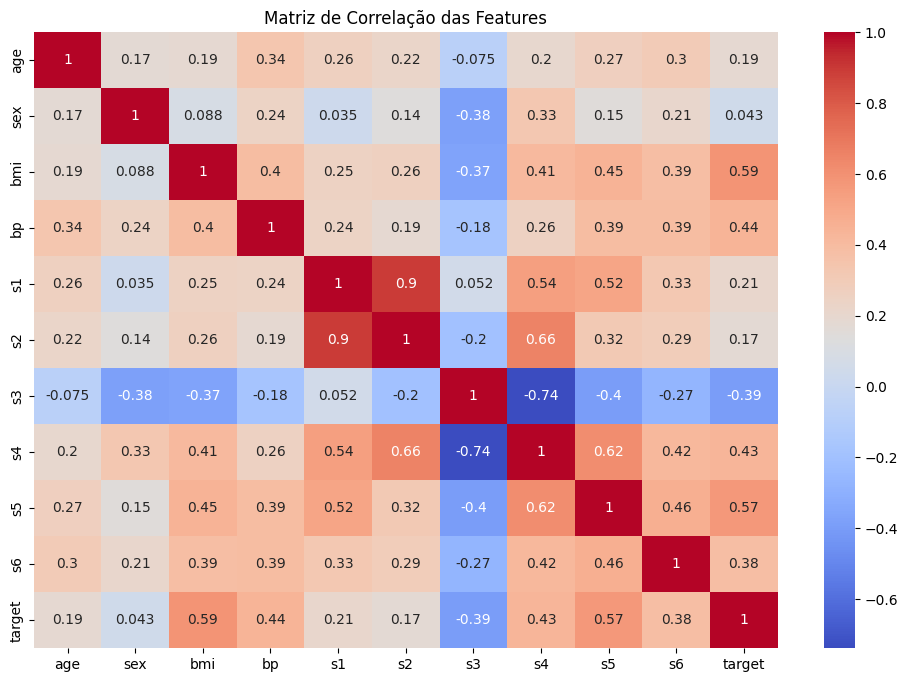

In [7]:
# Criando um heatmap com a matriz de correlação para melhor visualização
plt.figure(figsize=(12, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlação das Features')
plt.show()

Features com maior correlação com o target: bmi e s5.

Features com menor correlação com o target: s2, age e s1.

Também podemos perceber que o bmi e o s5 possuem grande correlação entre si --> Não sei se o suficente para considerar uma única informação, mas, caso seja preciso substituir, podemos considerar as próximas features como: bp, sex e s4.

Considerando que a partir de 0.4 seja uma correlação grande demais para duas features, poderíamos pensar em possibilidades como:
- bmi (0.59) e sex (0.43) --> com 0.088 de correlação entre elas;
- s5 (0.57) e sex (0.43) --> com 0.15 de correlação entre elas;
- s5 (0.57) e bp (0.44) --> com 0.39 de correlação entre elas (no limite);
- bp (0.44) e sex (0.43) --> com 0.24 de correlação entre elas;
- bp (0.44) e s4 (0.43) --> com 0.26 de correlação entre elas;
- sex (0.43) e s4 (0.43) --> com 0.33 de correlação entre elas.

#### Os atributos estão em escalas comparáveis? Será necessário normalizar/reescalar as features? Por quê?

In [8]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


Mesmo que os mínimos e máximos variem bastante, todos os desvios padrão são iguais, portanto, nenhuma feature precisa ser reescalada.

## 3 - Modelo Inicial com Todas as Features

In [9]:
# Treino e Teste 80/20
X = diabetes().data
y = diabetes().target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
# Regressão Linear com todas as features
reg = LinearRegression()
reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)

# Coeficientes
coef = pd.Series(reg.coef_, index=diabetes().feature_names)
print("Coeficientes de cada Feature:")
print(coef.abs().sort_values(ascending=False))

# Intercepto
intercept = reg.intercept_
print("\nIntercepto:", intercept)

# R² no treino
r2_train = reg.score(X_train, y_train)
print("R² treino:", r2_train)

# R² no teste
r2_test = reg.score(X_test, y_test)
print("R² teste:", r2_test)

# R² na predição
# Não entendi pra que usar uma sintaxe diferente na predição, mas tá aqui o da predição e o do teste é a mesma coisa :)
r2 = r2_score(y_test, y_pred)
print("R² predição:", r2)

Coeficientes de cada Feature:
s1     931.488846
s5     736.198859
bmi    542.428759
s2     518.062277
bp     347.703844
s4     275.317902
sex    241.964362
s3     163.419983
s6      48.670657
age     37.904021
dtype: float64

Intercepto: 151.34560453985995
R² treino: 0.5279193863361497
R² teste: 0.4526027629719195
R² predição: 0.4526027629719195


## 4 - Seleção de Features com Correlação

In [11]:
# As features com menor correlação com o target são s2, age e s1, então vamos retirar elas e ver como fica a regressão

# Retirando a coluna target, junto com as features com menor correlação
df_corr = df.drop(columns=['s2', 'age', 's1', 'target'])

# Criando novo X
X_corr = df_corr.values

# print(X, X_corr)

In [12]:
# Criando nova regressão com as features retiradas
X_train_corr, X_test_corr, y_train_corr, y_test_corr = train_test_split(X_corr, y, test_size=0.2, random_state=42)

reg_corr = LinearRegression()
reg_corr.fit(X_train_corr, y_train_corr)

y_pred_corr = reg_corr.predict(X_test_corr)

# Coeficientes
coef_corr = pd.Series(reg_corr.coef_, index=df_corr.columns)
print("Coeficientes de cada Feature:")
print(coef_corr.abs().sort_values(ascending=False))

# Intercepto
intercept_corr = reg_corr.intercept_
print("\nIntercepto:", intercept_corr)

# R² no treino
r2_train_corr = reg_corr.score(X_train_corr, y_train_corr)
print("R² treino:", r2_train_corr)

# R² no teste
r2_test_corr = reg_corr.score(X_test_corr, y_test_corr)
print("R² teste:", r2_test_corr)

# R² na predição
r2_corr = r2_score(y_test_corr, y_pred_corr)
print("R² predição:", r2_corr)

Coeficientes de cada Feature:
bmi    551.664881
s5     449.862347
s3     381.381130
bp     337.694767
sex    224.316182
s4     117.323304
s6      51.571470
dtype: float64

Intercepto: 151.4444285018145
R² treino: 0.5167268925203578
R² teste: 0.47228480061080047
R² predição: 0.47228480061080047


## 5 - Comparação e Reflexão

In [13]:
# Comparando as duas regressões
print(f'Regressão com todas as features vs Regressão com features retiradas (s2, age e s1):\n')

# Coeficientes
print("Coeficientes de Todas as Features:")
print(coef.abs().sort_values(ascending=False))

print("\nCoeficientes com as Features Retiradas:")
print(coef_corr.abs().sort_values(ascending=False))

# Intercepto
print("\nIntercepto de Todas as Features:", intercept)
print("Intercepto das Features Retiradas:", intercept_corr)

# R² no treino
print("\nR² treino de Todas as Features:", r2_train)
print("R² treino das Features Retiradas:", r2_train_corr)

# R² no teste
print("\nR² teste de Todas as Features:", r2_test)
print("R² teste das Features Retiradas:", r2_test_corr)

# R² na predição
print("\nR² predição de Todas as Features:", r2)
print("R² predição das Features Retiradas:", r2_corr)

Regressão com todas as features vs Regressão com features retiradas (s2, age e s1):

Coeficientes de Todas as Features:
s1     931.488846
s5     736.198859
bmi    542.428759
s2     518.062277
bp     347.703844
s4     275.317902
sex    241.964362
s3     163.419983
s6      48.670657
age     37.904021
dtype: float64

Coeficientes com as Features Retiradas:
bmi    551.664881
s5     449.862347
s3     381.381130
bp     337.694767
sex    224.316182
s4     117.323304
s6      51.571470
dtype: float64

Intercepto de Todas as Features: 151.34560453985995
Intercepto das Features Retiradas: 151.4444285018145

R² treino de Todas as Features: 0.5279193863361497
R² treino das Features Retiradas: 0.5167268925203578

R² teste de Todas as Features: 0.4526027629719195
R² teste das Features Retiradas: 0.47228480061080047

R² predição de Todas as Features: 0.4526027629719195
R² predição das Features Retiradas: 0.47228480061080047


Percebemos que, ao retirar as features com menor correlação com o target, o R² de teste aumenta (mesmo o do treino tendo diminuído).

Além disso, os primeiros coeficientes, ou seja, os que mais influenciam o modelo, são os dois com maior correlação com o target (bmi e s5)

# Parte B

In [ ]:
# Apenas escalamos para melhorar a visualização dos resíduos ortogonais no gráfico :)
scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_bmi_scaled = scaler_x.fit_transform(df[["bmi"]])
y_scaled = scaler_y.fit_transform(df[["target"]].values.reshape(-1, 1)).flatten()

X_train_bmi, X_test_bmi, y_train_bmi, y_test_bmi = train_test_split(
    X_bmi_scaled, y_scaled, test_size=0.2, random_state=42
)

reg_bmi = LinearRegression()
reg_bmi.fit(X_train_bmi, y_train_bmi)

y_pred_bmi = reg_bmi.predict(X_test_bmi)


## 1 - Regressão Linear Ordinária (OLS)

Coeficiente OLS (a): 0.6168045832227347
Intercepto OLS (b): -0.0016898732288770715
R² treino: 0.36572412737941273
R² teste: 0.23335039815872138
R² predição: 0.23335039815872138
Root Mean Squared Error (RMSE): 0.8276324724736294


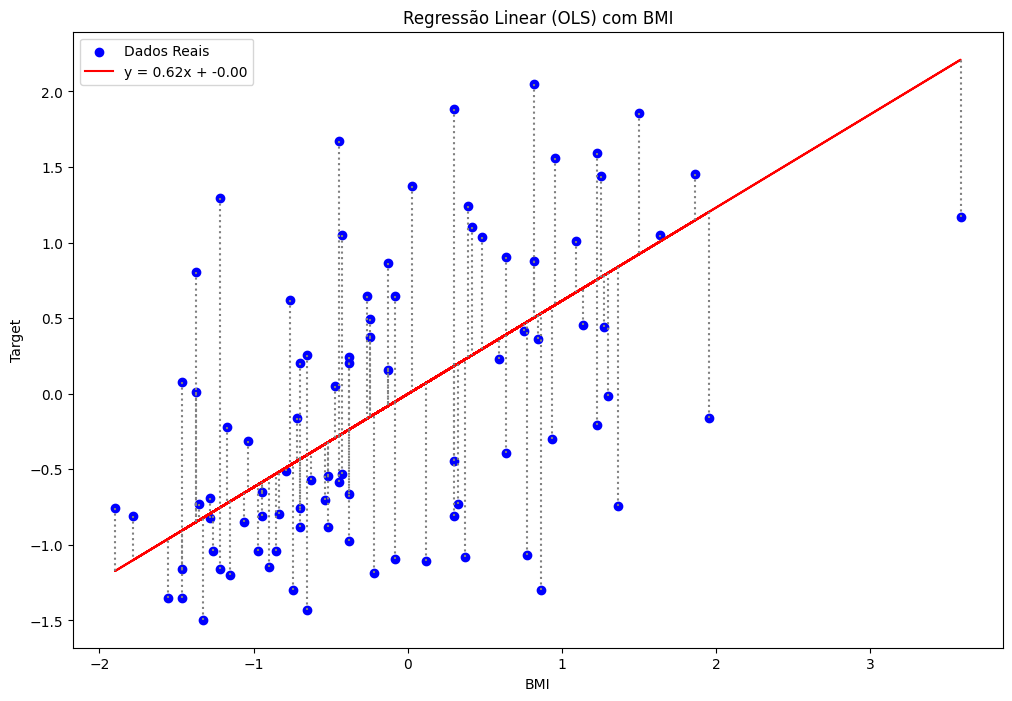

In [40]:
# Coeficiente
coeficiente_bmi = reg_bmi.coef_[0]
print("Coeficiente OLS (a):", coeficiente_bmi)

# Intercepto
intercept_bmi = reg_bmi.intercept_
print("Intercepto OLS (b):", intercept_bmi)

# R² no treino
r2_train_bmi = reg_bmi.score(X_train_bmi, y_train_bmi)
print("R² treino:", r2_train_bmi)

# R² no teste
r2_test_bmi = reg_bmi.score(X_test_bmi, y_test_bmi)
print("R² teste:", r2_test_bmi)

# R² na predição
r2_bmi = r2_score(y_test_bmi, y_pred_bmi)
print("R² predição:", r2_bmi)

# RMSE no conjunto de teste
mse = mean_squared_error(y_test_bmi, y_pred_bmi)
rmse = np.sqrt(mse)
print("Root Mean Squared Error (RMSE):", rmse)

# Plotando a regressão, mostrando alguns resíduos verticais
plt.figure(figsize=(12, 8))
plt.scatter(X_test_bmi, y_test_bmi, color='blue', label='Dados Reais')
plt.plot(X_test_bmi, y_pred_bmi, color='red', label=f'y = {coeficiente_bmi:.2f}x + {intercept_bmi:.2f}')
plt.vlines(X_test_bmi, y_test_bmi, y_pred_bmi, color='gray', linestyle='dotted')
plt.xlabel('BMI')
plt.ylabel('Target')
plt.title('Regressão Linear (OLS) com BMI')
plt.legend()
plt.show()

## 2 - Regressão por Distância Ortogonal (ODR/TLS)

Coeficiente ODR (a): 0.8794308458489977
Intercepto ODR (b): 0.05891618737718396
R² treino: não existe, uma vez que a regressão do scikit learn não funciona para a regressão ODR?
R² predição: 0.0655456036473181
Root Mean Squared Error (RMSE): 0.9137304975999503


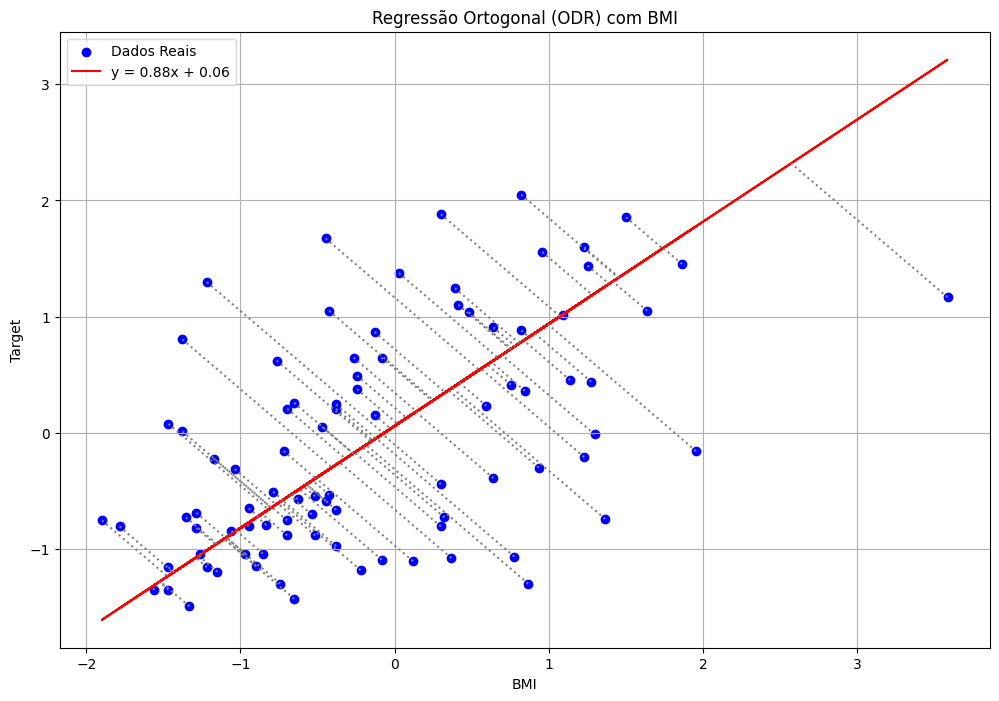

In [ ]:
# Fórmula com erro conforme documento word
def calcula_erro_ortogonal(a, b, x, y):
    erro = 0
    for xi, yi in zip(x, y):
        numerador = abs(a * xi - yi + b) # ax0 - y0 + b
        denominador = np.sqrt(a**2 + 1) # raiz quadrada de a^2 + 1
        d = numerador / denominador # d = (ax0 - y0 + b) / (raiz quadrada de a^2 + 1)
        erro += d**2
    return erro

data_x = X_test_bmi.flatten()
data_y = y_test_bmi

# Geração da grade de coeficientes de acordo com os coeficientes OLS
A = np.linspace(coeficiente_bmi[0] - 2, coeficiente_bmi[0] + 2, 100)
B= np.linspace(intercept_bmi - 2, intercept_bmi + 2, 100)

# Achar a e b
erros = np.zeros((len(A), len(B)))
menor = calcula_erro_ortogonal(A[0], B[0], data_x, data_y)
valores = [A[0], B[0], menor]
for i, a in enumerate(A):
    for j, b in enumerate(B):
        erro = calcula_erro_ortogonal(a, b, data_x, data_y)
        erros[i][j] = erro
        if erro < menor:
            menor = erro
            valores = [a, b, erro]

# Coeficientes finais
a, b = valores[0], valores[1]
print("Coeficiente ODR (a):", a)
print("Intercepto ODR (b):", b)

# Predição com a reta ortogonal
y_pred_odr = a * data_x + b

# R² no treino
print("R² treino: não existe, uma vez que a regressão do scikit learn não funciona para a regressão ODR?")

# R² na predição
r2_odr = r2_score(data_y, y_pred_odr)
print("R² predição:", r2_odr)

# RMSE no conjunto de teste
rmse_odr = np.sqrt(mean_squared_error(data_y, y_pred_odr))
print("Root Mean Squared Error (RMSE):", rmse_odr)

# Gráfico da regressão ortogonal com resíduos
plt.figure(figsize=(12, 8))
plt.scatter(data_x, data_y, color='blue', label='Dados Reais')
plt.plot(data_x, y_pred_odr, color='red', label=f'y = {a:.2f}x + {b:.2f}')

# Resíduos ortogonais
for xi, yi in zip(data_x, data_y):
    # Projeção ortogonal do ponto (xi, yi) na reta y = ax + b
    x_proj = (xi + a * (yi - b)) / (a**2 + 1) # cálculo da projeção ortogonal
    y_proj = a * x_proj + b # cálculo da reta de acordo com o erro
    plt.plot([xi, x_proj], [yi, y_proj], color='gray', linestyle='dotted') # linha ortogonal entre reta-dado

plt.xlabel('BMI')
plt.ylabel('Target')
plt.title('Regressão Ortogonal (ODR) com BMI')
plt.legend()
plt.grid(True)
plt.show()

## 3 - Discussão:

### Em que situações OLS e ODR resultam em retas significativamente diferentes?
Elas vão resultar em retas com diferenças significativas quando os dados em X
apresentarem erros que não podemos desprezar, ou seja, quando ambos os dados utilizados
apresentam erros significativos. Já que OLS assume um X sem erros ou insignificantes,
enquanto ODR assume erro em ambos.


### Por que ODR é mais adequado quando tanto X quanto Y têm erro de medição?
Porque ele encontra a reta que minimiza a soma das distancias ortogonais levando em
conta tanto a direção X quanto a Y. O que não ocorre no OLS, onde qualquer desvio observado
seria atribuido a Y, pois seu cálculo da distancia assume um X sem erros de medição


### Como a escala/unidades das variáveis afetam a solução ODR (e por que padronizar é útil)?
O cálculo ODR é sensível a escala das variáveis pois a distância ortogonal depende das
magnitudes de X e Y. Se uma variável tiver valores muito maiores que a outra (por exemplo, X
em metros e Y em milímetros), ela dominará a minimização e distorcerá o ajuste. Por isso,
padronizar os dados, trazer todas as variáveis para a mesma escala, garante que cada eixo
contribua de forma equilibrada no cálculo da distância e na inclinação da reta.

### Qual modelo parece generalizar melhor e segundo qual critério?
Depende do contexto dos dados e do desempenho do cálculo na previsão com dados
independentes:

Se apenas Y apresenta erros significativos e o X for preciso e/ou apresenta erros
irrelevantes, o OLS provavelmente generalizará melhor, pois seu cálculo já parte do
pressuposto de que X não afetará a predição de Y, por exemplo, nesse caso, podemos avaliar
o desempenho da previsão ao verificar o erro quadrático médio

Se ambas as variáveis (X e Y) têm erro de medição, o ODR generaliza melhor. Pois ele
fornece estimativas de parâmetros que representam mais fielmente o comportamento real dos
dados, no caso, s

# Teste

NameError: name 'best_m' is not defined

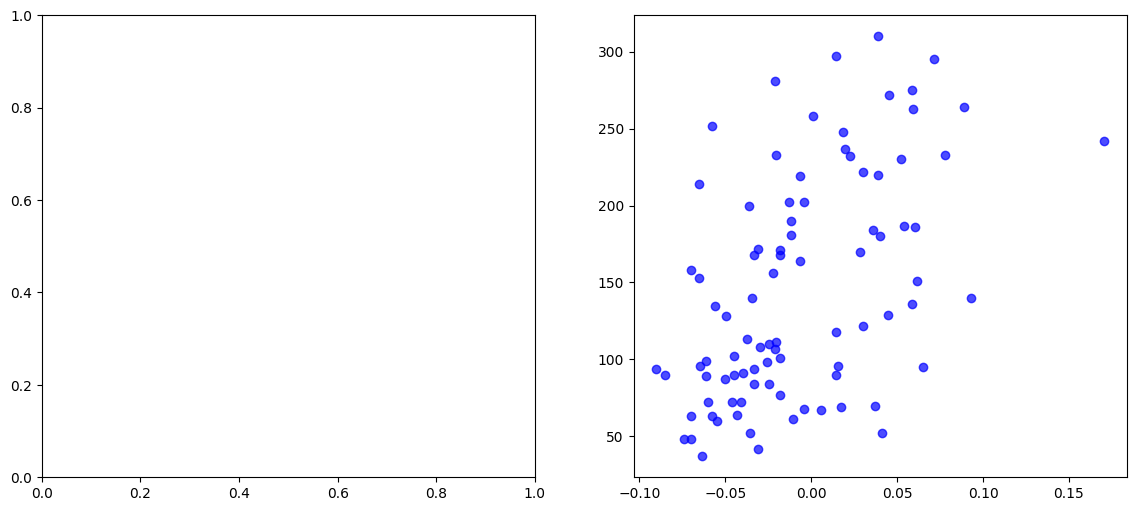

In [18]:
# Plot ODR com distâncias ortogonais
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax2.scatter(X_test_bmi, y_test_bmi, alpha=0.7, label='Dados reais', color='blue')
x_line_odr = np.linspace(X_test_bmi.min(), X_test_bmi.max(), 100)
y_line_odr = best_m * x_line_odr + best_b
ax2.plot(x_line_odr, y_line_odr, 'g-', linewidth=2, label='Reta ODR')

# Adicionar linhas ortogonais (resíduos ODR)
for i in range(len(X_test_bmi)):
    x0, y0 = X_test_bmi[i], y_test_bmi[i]
    # Encontrar ponto mais próximo na reta (projeção ortogonal)
    x_proj = (x0 + best_m * (y0 - best_b)) / (best_m**2 + 1)
    y_proj = best_m * x_proj + best_b
    ax2.plot([x0, x_proj], [y0, y_proj], 'g--', alpha=0.5, linewidth=0.8)

ax2.set_xlabel(f'{feature} (padronizado)')
ax2.set_ylabel('Progressão da Diabetes (padronizada)')
ax2.set_title('ODR - Minimiza Distâncias Ortogonais')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()